Transaction Data Validation & Risk Review

**Latar Belakang:** Sebelum data transaksi digunakan untuk pelaporan atau
pengambilan keputusan bisnis, perlu dipastikan dulu kelengkapan, konsistensi,
dan validitasnya terhadap data master (pelanggan, produk, toko).

**Tujuan:**
- Memverifikasi integritas data transaksi terhadap master data
- Mengidentifikasi transaksi yang menyimpang dari kebijakan (diskon, kelengkapan data)
- Menyajikan ringkasan kontrol untuk mendukung proses monitoring risiko & compliance

**Tools:** Python (pandas, matplotlib) — Google Colab

##Load Data

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

pelanggan = pd.read_csv('pelanggan-1.csv')
produk = pd.read_csv('produk-1.csv')
toko = pd.read_csv('toko-1.csv')
trx = pd.read_csv('transaksi_bersih.csv')

print("Jumlah baris:", len(pelanggan), len(produk), len(toko), len(trx))

Jumlah baris: 3480 312 13 10970


##Data Quality

In [10]:
trx['tanggal'] = pd.to_datetime(trx['tanggal'], format='%Y-%m-%d')

for col, df in [('segmen', pelanggan), ('kategori', produk), ('tipe', toko), ('channel', trx)]:
    df[col] = df[col].astype('category')

assert pelanggan['pelanggan_id'].duplicated().sum() == 0, "Ada pelanggan_id duplikat"
assert produk['produk_id'].duplicated().sum() == 0, "Ada produk_id duplikat"
assert toko['toko_id'].duplicated().sum() == 0, "Ada toko_id duplikat"
print("Cek duplikat ID master data: LOLOS")

id_toko_invalid = (~trx['toko_id'].isin(toko['toko_id'])).sum()
id_produk_invalid = (~trx['produk_id'].isin(produk['produk_id'])).sum()
id_pelanggan_invalid = (~trx['pelanggan_id'].dropna().isin(pelanggan['pelanggan_id'])).sum()
print(f"ID toko tidak valid: {id_toko_invalid}")
print(f"ID produk tidak valid: {id_produk_invalid}")
print(f"ID pelanggan tidak valid: {id_pelanggan_invalid}")

cek_harga = trx.merge(produk[['produk_id', 'harga_jual']], on='produk_id', how='left')
selisih_harga = (cek_harga['harga_satuan'] != cek_harga['harga_jual']).sum()
print(f"Transaksi dengan harga di luar price list resmi: {selisih_harga}")

Cek duplikat ID master data: LOLOS
ID toko tidak valid: 0
ID produk tidak valid: 0
ID pelanggan tidak valid: 0
Transaksi dengan harga di luar price list resmi: 0


#Flagging

In [11]:
BATAS_DISKON = 30
trx['flag_diskon_tinggi'] = trx['diskon_pct'] > BATAS_DISKON
trx['flag_ongkir_kosong'] = trx['biaya_kirim'].isnull() & (trx['channel'] != 'Toko')
trx['flag_walkin_toko'] = trx['pelanggan_id'].isnull() & (trx['channel'] == 'Toko')
trx['perlu_review'] = trx[['flag_diskon_tinggi', 'flag_ongkir_kosong']].any(axis=1)

print(f"Transaksi diskon > {BATAS_DISKON}%: {trx['flag_diskon_tinggi'].sum()} ({trx['flag_diskon_tinggi'].mean()*100:.1f}%)")
print(f"Transaksi online/marketplace tanpa data ongkir: {trx['flag_ongkir_kosong'].sum()}")
print(f"Transaksi walk-in toko tanpa pelanggan_id: {trx['flag_walkin_toko'].sum()}")
print(f"Total transaksi perlu review: {trx['perlu_review'].sum()} ({trx['perlu_review'].mean()*100:.1f}%)")

Transaksi diskon > 30%: 327 (3.0%)
Transaksi online/marketplace tanpa data ongkir: 156
Transaksi walk-in toko tanpa pelanggan_id: 358
Total transaksi perlu review: 477 (4.3%)


##Visualisasi

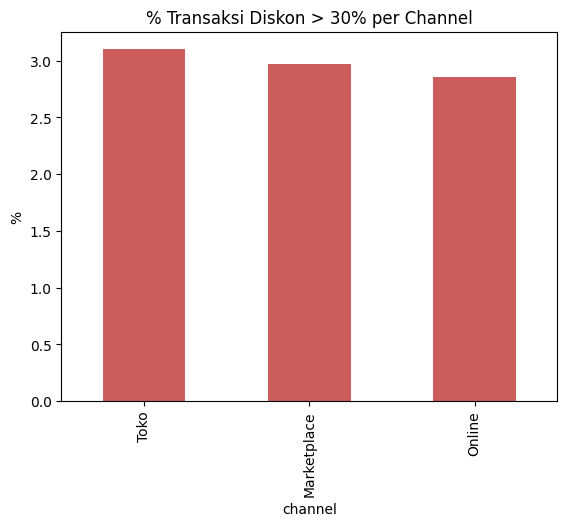

In [12]:
trx.groupby('channel', observed=True)['flag_diskon_tinggi'].mean().mul(100).sort_values(ascending=False).plot(
    kind='bar', title=f'% Transaksi Diskon > {BATAS_DISKON}% per Channel', color='indianred')
plt.ylabel('%')
plt.show()

##Ringkasan

In [13]:
ringkasan = pd.DataFrame({
    'Kontrol': [
        'ID toko valid', 'ID produk valid', 'ID pelanggan valid',
        'Harga sesuai price list resmi',
        f'Diskon sesuai batas kebijakan ({BATAS_DISKON}%)',
        'Ongkir tercatat (channel non-Toko)',
    ],
    'Status': [
        'Lolos', 'Lolos', 'Lolos', 'Lolos',
        f"{trx['flag_diskon_tinggi'].sum()} transaksi melebihi batas ({trx['flag_diskon_tinggi'].mean()*100:.1f}%)",
        f"{trx['flag_ongkir_kosong'].sum()} transaksi bermasalah",
    ]
})
ringkasan

,Kontrol,Status
0,ID toko valid,Lolos
1,ID produk valid,Lolos
2,ID pelanggan valid,Lolos
3,Harga sesuai price list resmi,Lolos
4,Diskon sesuai batas kebijakan (30%),327 transaksi melebihi batas (3.0%)
5,Ongkir tercatat (channel non-Toko),156 transaksi bermasalah


##Conclusion

- Seluruh data master (pelanggan, produk, toko) terverifikasi bersih — tidak ada
  duplikasi ID maupun nilai kosong.
- Seluruh transaksi (10.970 baris) menggunakan harga sesuai price list resmi —
  0 penyimpangan harga ditemukan.
- 327 transaksi (3,0%) memiliki diskon di atas batas kebijakan 30%, tersebar cukup
  merata di ketiga channel — tidak mengindikasikan masalah pada channel tertentu,
  namun tetap perlu ditelusuri otorisasinya.
- 156 transaksi online/marketplace tidak memiliki data ongkir tercatat — ini celah
  kelengkapan data yang perlu dikoordinasikan dengan tim terkait.
- 358 transaksi walk-in di toko fisik tanpa pelanggan_id — pola ini wajar (pembeli
  tanpa akun member) dan tidak diklasifikasikan sebagai anomali.

**Rekomendasi:** tinjau ulang 327 transaksi dengan diskon tinggi untuk memastikan
ada otorisasi yang sah, dan koordinasi dengan tim pencatatan transaksi untuk
menutup celah data ongkir pada channel online/marketplace.